In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [ ]:
import requests
import json
API_KEY = "e6d216bdd30fc098485b192c3e990f6a"   # Replace with your OpenWeatherMap API key
CITY = "Nashik"
URL = f"https://api.openweathermap.org/data/2.5/forecast?q={CITY}&appid={API_KEY}&units=metric"

# Step 3: Fetch data from OpenWeatherMap
response = requests.get(URL)
data = response.json()
data

{'cod': '200',
 'message': 0,
 'cnt': 40,
 'list': [{'dt': 1762592400,
   'main': {'temp': 26.25,
    'feels_like': 26.25,
    'temp_min': 26.25,
    'temp_max': 27.42,
    'pressure': 1015,
    'sea_level': 1015,
    'grnd_level': 940,
    'humidity': 37,
    'temp_kf': -1.17},
   'weather': [{'id': 800,
     'main': 'Clear',
     'description': 'clear sky',
     'icon': '01d'}],
   'clouds': {'all': 2},
   'wind': {'speed': 4.2, 'deg': 317, 'gust': 3.56},
   'visibility': 10000,
   'pop': 0,
   'sys': {'pod': 'd'},
   'dt_txt': '2025-11-08 09:00:00'},
  {'dt': 1762603200,
   'main': {'temp': 23.76,
    'feels_like': 23.52,
    'temp_min': 22.81,
    'temp_max': 23.76,
    'pressure': 1015,
    'sea_level': 1015,
    'grnd_level': 941,
    'humidity': 51,
    'temp_kf': 0.95},
   'weather': [{'id': 800,
     'main': 'Clear',
     'description': 'clear sky',
     'icon': '01d'}],
   'clouds': {'all': 1},
   'wind': {'speed': 3.6, 'deg': 324, 'gust': 5.68},
   'visibility': 10000,
   'p

In [ ]:
weather_list = data["list"]

weather_data = []
for item in weather_list:
    dt = datetime.fromtimestamp(item["dt"])
    temp = item["main"]["temp"]
    temp_min = item["main"]["temp_min"]
    temp_max = item["main"]["temp_max"]
    humidity = item["main"]["humidity"]
    wind_speed = item["wind"]["speed"]
    description = item["weather"][0]["description"]

    weather_data.append([dt, temp, temp_min, temp_max, humidity, wind_speed, description])

In [ ]:
df = pd.DataFrame(weather_data, columns=["DateTime", "Temp", "Temp_Min", "Temp_Max", "Humidity", "Wind_Speed", "Description"])
df

,DateTime,Temp,Temp_Min,Temp_Max,Humidity,Wind_Speed,Description
0,2025-11-08 09:00:00,26.25,26.25,27.42,37,4.20,clear sky
1,2025-11-08 12:00:00,23.76,22.81,23.76,51,3.60,clear sky
2,2025-11-08 15:00:00,19.75,19.75,19.75,54,1.68,clear sky
3,2025-11-08 18:00:00,18.74,18.74,18.74,51,0.89,clear sky
4,2025-11-08 21:00:00,17.22,17.22,17.22,52,1.82,clear sky
5,2025-11-09 00:00:00,16.25,16.25,16.25,52,1.75,clear sky
6,2025-11-09 03:00:00,19.29,19.29,19.29,51,2.34,clear sky
7,2025-11-09 06:00:00,24.79,24.79,24.79,37,3.15,clear sky
8,2025-11-09 09:00:00,26.43,26.43,26.43,30,1.90,clear sky
9,2025-11-09 12:00:00,23.57,23.57,23.57,40,1.25,clear sky


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DateTime     40 non-null     datetime64[ns]
 1   Temp         40 non-null     float64       
 2   Temp_Min     40 non-null     float64       
 3   Temp_Max     40 non-null     float64       
 4   Humidity     40 non-null     int64         
 5   Wind_Speed   40 non-null     float64       
 6   Description  40 non-null     object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 2.3+ KB


In [ ]:
df.isnull().sum()

,0
DateTime,0
Temp,0
Temp_Min,0
Temp_Max,0
Humidity,0
Wind_Speed,0
Description,0


In [ ]:
df.shape

(40, 7)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df

,DateTime,Temp,Temp_Min,Temp_Max,Humidity,Wind_Speed,Description
0,2025-11-08 09:00:00,26.25,26.25,27.42,37,4.20,clear sky
1,2025-11-08 12:00:00,23.76,22.81,23.76,51,3.60,clear sky
2,2025-11-08 15:00:00,19.75,19.75,19.75,54,1.68,clear sky
3,2025-11-08 18:00:00,18.74,18.74,18.74,51,0.89,clear sky
4,2025-11-08 21:00:00,17.22,17.22,17.22,52,1.82,clear sky
5,2025-11-09 00:00:00,16.25,16.25,16.25,52,1.75,clear sky
6,2025-11-09 03:00:00,19.29,19.29,19.29,51,2.34,clear sky
7,2025-11-09 06:00:00,24.79,24.79,24.79,37,3.15,clear sky
8,2025-11-09 09:00:00,26.43,26.43,26.43,30,1.90,clear sky
9,2025-11-09 12:00:00,23.57,23.57,23.57,40,1.25,clear sky


In [ ]:
df.shape

(40, 7)

In [ ]:
print("Humidity Range:", df["Humidity"].min(), "to", df["Humidity"].max())

Humidity Range: 25 to 57


In [ ]:
print("Temperature Range:", df["Temp"].min(), "to", df["Temp"].max())

Temperature Range: 15.6 to 26.71


In [ ]:
df.describe()

,DateTime,Temp,Temp_Min,Temp_Max,Humidity,Wind_Speed
count,40,40.000000,40.000000,40.000000,40.000000,40.000000
mean,2025-11-10 19:30:00,20.472250,20.448500,20.501500,42.175000,1.987750
min,2025-11-08 09:00:00,15.600000,15.600000,15.600000,25.000000,0.360000
25%,2025-11-09 14:15:00,17.520000,17.520000,17.520000,37.750000,1.507500
50%,2025-11-10 19:30:00,19.320000,19.320000,19.320000,42.000000,1.760000
75%,2025-11-12 00:45:00,23.970000,23.827500,23.970000,47.250000,2.317500
max,2025-11-13 06:00:00,26.710000,26.710000,27.420000,57.000000,5.090000
std,NaN,3.698122,3.679469,3.749266,7.738971,0.995494


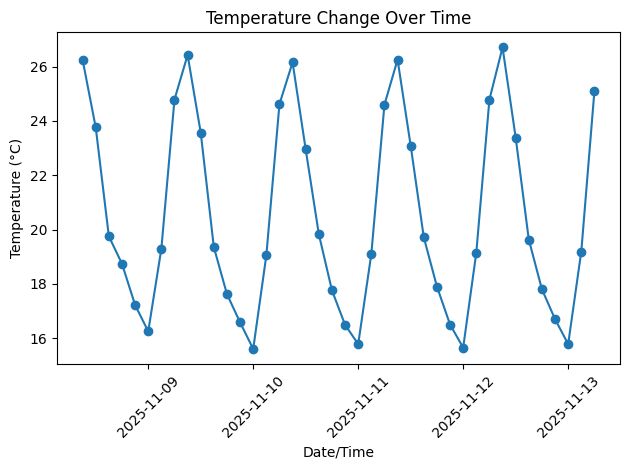

In [ ]:
plt.plot(df["DateTime"], df["Temp"], marker='o')
plt.title("Temperature Change Over Time")
plt.xlabel("Date/Time"); plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


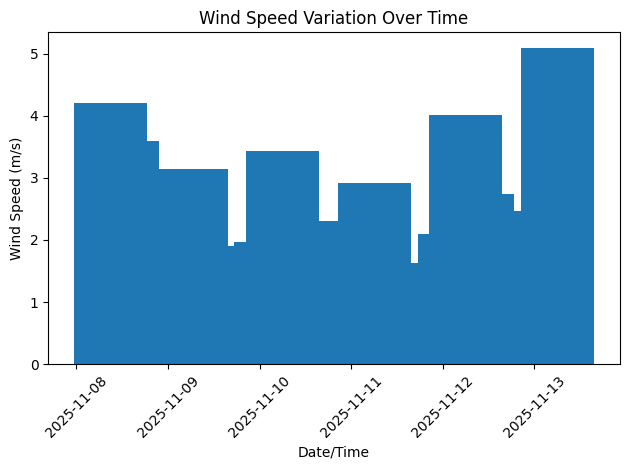

In [ ]:
plt.bar(df["DateTime"], df["Wind_Speed"])
plt.title("Wind Speed Variation Over Time")
plt.xlabel("Date/Time"); plt.ylabel("Wind Speed (m/s)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


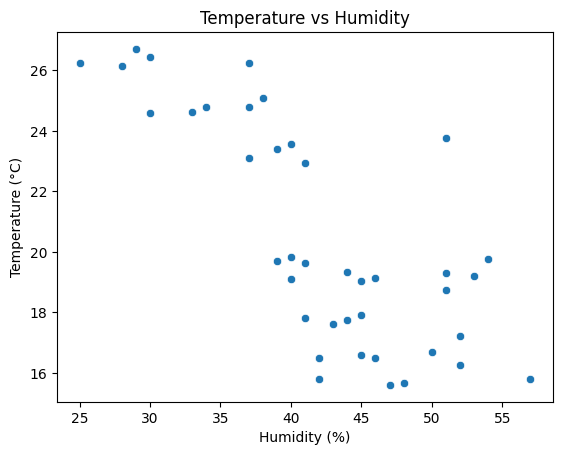

In [ ]:
sns.scatterplot(data=df, x="Humidity", y="Temp")
plt.title("Temperature vs Humidity")
plt.xlabel("Humidity (%)"); plt.ylabel("Temperature (°C)")
plt.show()


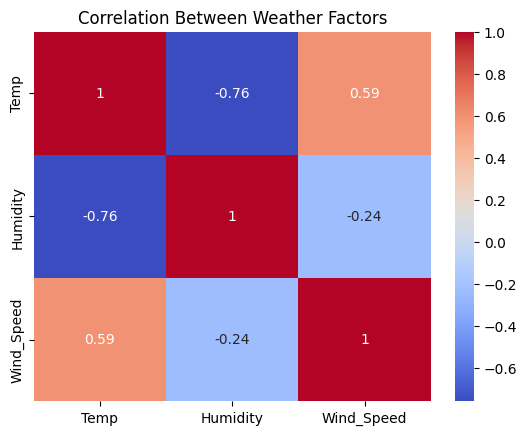

In [ ]:
sns.heatmap(df[["Temp","Humidity","Wind_Speed"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Weather Factors")
plt.show()


In [ ]:
df["Date"] = df["DateTime"].dt.date
df["Month"] = df["DateTime"].dt.month_name()
df

,DateTime,Temp,Temp_Min,Temp_Max,Humidity,Wind_Speed,Description,Date,Month
0,2025-11-08 09:00:00,26.25,26.25,27.42,37,4.20,clear sky,2025-11-08,November
1,2025-11-08 12:00:00,23.76,22.81,23.76,51,3.60,clear sky,2025-11-08,November
2,2025-11-08 15:00:00,19.75,19.75,19.75,54,1.68,clear sky,2025-11-08,November
3,2025-11-08 18:00:00,18.74,18.74,18.74,51,0.89,clear sky,2025-11-08,November
4,2025-11-08 21:00:00,17.22,17.22,17.22,52,1.82,clear sky,2025-11-08,November
5,2025-11-09 00:00:00,16.25,16.25,16.25,52,1.75,clear sky,2025-11-09,November
6,2025-11-09 03:00:00,19.29,19.29,19.29,51,2.34,clear sky,2025-11-09,November
7,2025-11-09 06:00:00,24.79,24.79,24.79,37,3.15,clear sky,2025-11-09,November
8,2025-11-09 09:00:00,26.43,26.43,26.43,30,1.90,clear sky,2025-11-09,November
9,2025-11-09 12:00:00,23.57,23.57,23.57,40,1.25,clear sky,2025-11-09,November


In [ ]:
daily_summary = df.groupby("Date").agg({
    "Temp": "mean",
    "Humidity": "mean",
    "Wind_Speed": "mean"
}).reset_index()

print(" Daily Weather Summary:")
daily_summary.head()


 Daily Weather Summary:


,Date,Temp,Humidity,Wind_Speed
0,2025-11-08,21.1440,49.00,2.43800
1,2025-11-09,20.4850,42.75,1.86250
2,2025-11-10,20.3075,40.00,1.67125
3,2025-11-11,20.3675,38.00,1.55000
4,2025-11-12,20.4775,41.00,2.14875


In [ ]:
!pip install folium

In [ ]:
import folium, requests, pandas as pd
from folium.plugins import HeatMap

In [ ]:
API_KEY = "e6d216bdd30fc098485b192c3e990f6a"
cities = ["Nashik","Mumbai","Pune"]

rows = []
for c in cities:
    r = requests.get("https://api.openweathermap.org/data/2.5/weather",
                     params={"q": c, "appid": API_KEY, "units":"metric"}).json()
    if r.get("cod") == 200:
        rows.append({"city": c,
                     "lat": r["coord"]["lat"],
                     "lon": r["coord"]["lon"],
                     "temp": r["main"]["temp"],
                     "humidity": r["main"]["humidity"],
                     "wind": r["wind"]["speed"]})
df_map = pd.DataFrame(rows); df_map


,city,lat,lon,temp,humidity,wind
0,Nashik,19.9833,73.8000,25.74,39,2.03
1,Mumbai,19.0144,72.8479,31.99,35,4.63
2,Pune,18.5196,73.8553,26.89,39,1.97


In [ ]:
m = folium.Map(location=[19.99,73.79], zoom_start=6)
for _, x in df_map.iterrows():
    folium.CircleMarker(
        location=[x.lat, x.lon],
        radius=8,
        popup=f"{x.city}: {x.temp}°C | Hum {x.humidity}% | Wind {x.wind} m/s",
        tooltip=x.city,
        fill=True
    ).add_to(m)
m


In [ ]:
m2 = folium.Map(location=[19.99,73.79], zoom_start=6)
HeatMap(df_map[["lat","lon","temp"]].values.tolist(), radius=25).add_to(m2)
m2


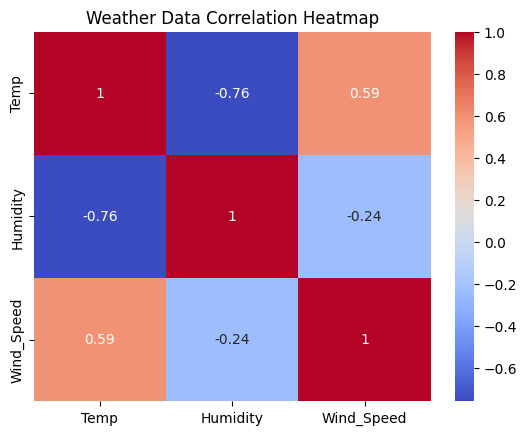

In [ ]:
sns.heatmap(df[["Temp","Humidity","Wind_Speed"]].corr(), annot=True, cmap="coolwarm")
plt.title("Weather Data Correlation Heatmap")
plt.show()

In [ ]:
m.save("maharashtra_weather_markers.html")
m2.save("maharashtra_weather_heatmap.html")
print("Saved HTML files.")

Saved HTML files.
